In [1]:
import PeterChurchillFunctions as Function
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import erf
import statsmodels.api as sm
from scipy.odr import ODR, Model, RealData
from matplotlib.colors import LogNorm


In [2]:
NorPath = "/share/sabl0586/all_stations_NorESM_OsloAero_prcp2szdst_f19_f19_noresmv211_corr_ilevall_levs_4Peter.nc"
ds = xr.open_dataset(NorPath, chunks={})
stations = ds["station"].values
print(stations)

['ZEP' 'SMR-II' 'ATTO' 'MHD' 'SGP' 'CHC' 'BIR-II' 'PAL' 'Vavihill' 'JFJ'
 'FKL' 'SMEAR-I' 'Villum' 'Izana' 'Maldives']


In [3]:
ECPath = "/share/sabl0586/all_stations_EC-Earth_PRCP2SZDST_ilevall_levs_4Peter.nc"
station='MHD'
VarList = ['FREQL', 'AWNC', 'WSUB', 'T', ]
ifs_vars = ['var130','var131','var132','var20','var21','var22','var248']
ifs_vars_names = ['temp','U','V','CDNC','re_liq','Liquid_Cloud_time','Cloud_Frac']
x = xr.DataArray(np.logspace(-0.5,3, num=200), dims =['D'], coords= {'D':np.logspace(-0.5,3, num=200)})

In [4]:
Nor_ds = Function.NorESMExtract_Dask(NorPath, station, VarList, x, PNSD = False)

In [5]:
radii = np.arange(20,51)
CCN_ds = Function.NorERF(Nor_ds, radii)

In [6]:
def Suceptibility_by_Level(CCN_ds, CDNC_da):
    """
    Compute OLS slope/intercept between CCN(radius, lev, time)
    and CDNC(lev, time) across 'time'.
    """
    CCN_aligned, CDNC_aligned = xr.align(CCN_ds, CDNC_da)

    OLS_slope, OLS_intercept = xr.apply_ufunc(
        Function.OLS_fit,
        np.log10(CCN_aligned),
        np.log10(CDNC_aligned),
        input_core_dims=[['time'], ['time']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float],
    )
    ODR_slope, ODR_intercept = xr.apply_ufunc(
        Function.TLS_fit,
        np.log10(CCN_aligned),
        np.log10(CDNC_aligned),
        input_core_dims=[['time'], ['time']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float],
    )
    Deming_slope, Deming_intercept = xr.apply_ufunc(
        Function.deming_fit,
        np.log10(CCN_aligned),
        np.log10(CDNC_aligned),
        input_core_dims=[['time'], ['time']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float],
    )
    PCA_slope, PCA_intercept = xr.apply_ufunc(
        Function.PCA_fit,
        np.log10(CCN_aligned),
        np.log10(CDNC_aligned),
        input_core_dims=[['time'], ['time']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float],
    )

    ds_out = xr.Dataset(
        data_vars={
            'OLS slope': (('radius', 'lev'), OLS_slope.data),
            'OLS intercept': (('radius', 'lev'), OLS_intercept.data),
            'ODR slope': (('radius', 'lev'), ODR_slope.data),
            'ODR intercept': (('radius', 'lev'), ODR_intercept.data),
            'Deming slope': (('radius', 'lev'), Deming_slope.data),
            'Deming intercept': (('radius', 'lev'), Deming_intercept.data),
            'PCA slope': (('radius', 'lev'), PCA_slope.data),
            'PCA intercept': (('radius', 'lev'), PCA_intercept.data),
        },
        coords={
            'radius': CCN_aligned.radius,
            'lev': CCN_aligned.lev
        }
    )

    return ds_out


In [7]:
Level_susc_ds = Suceptibility_by_Level(CCN_ds, Nor_ds['CDNC'])


OLS


/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


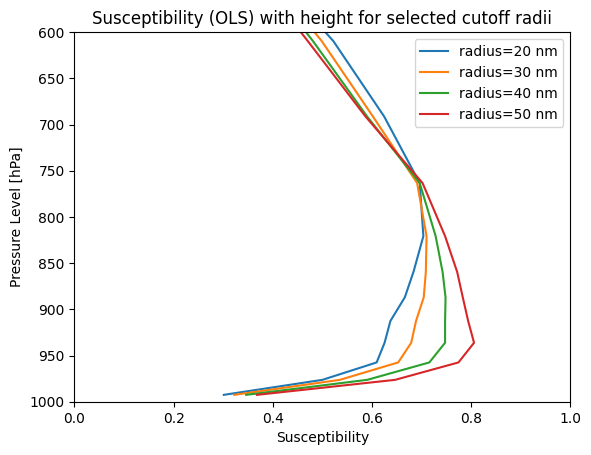

ODR


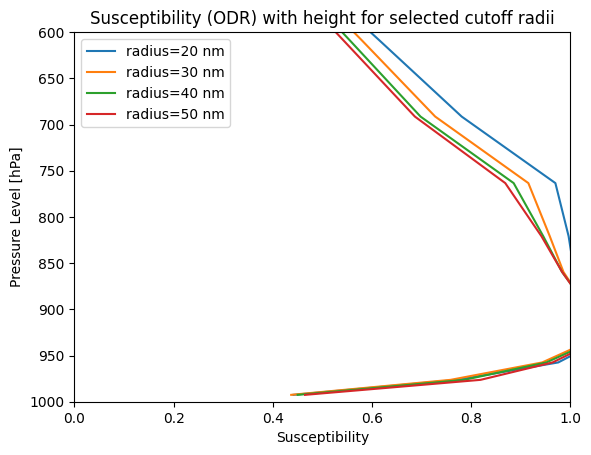

Deming


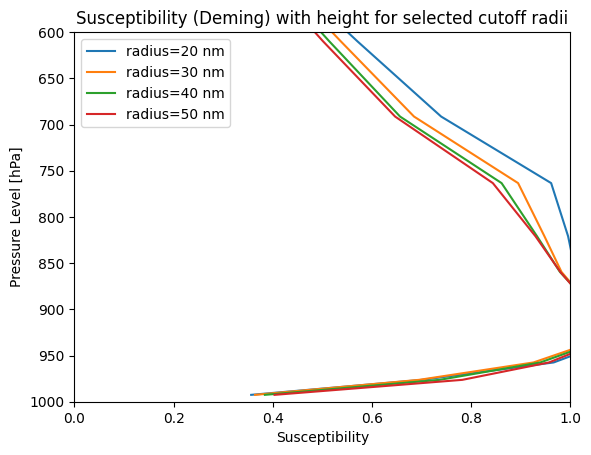

PCA


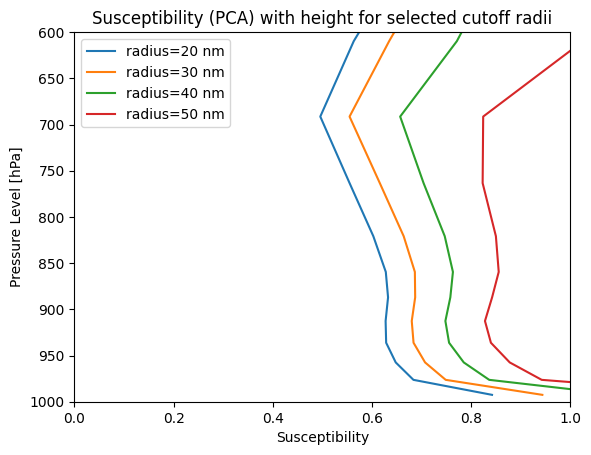

/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


In [8]:
def PLOTSusc_by_Level(ds = Level_susc_ds, Fit = 'OLS'):
    radii_to_plot = [20, 30, 40, 50]
    for r in radii_to_plot:
        ds[f'{Fit} slope'].sel(radius=r).plot(
            y='lev', 
            yincrease=False, 
            ylim=[1000, 600],
            xlim = [0,1],
            label=f'radius={r} nm'
        )
    
    plt.legend()
    plt.xlabel("Susceptibility")
    plt.ylabel("Pressure Level [hPa]")
    plt.title(f"Susceptibility ({Fit}) with height for selected cutoff radii")
    plt.show()

FitType = ['OLS', 'ODR', 'Deming', 'PCA']
for fit in FitType:
    print(fit)
    PLOTSusc_by_Level(Level_susc_ds, Fit = fit)


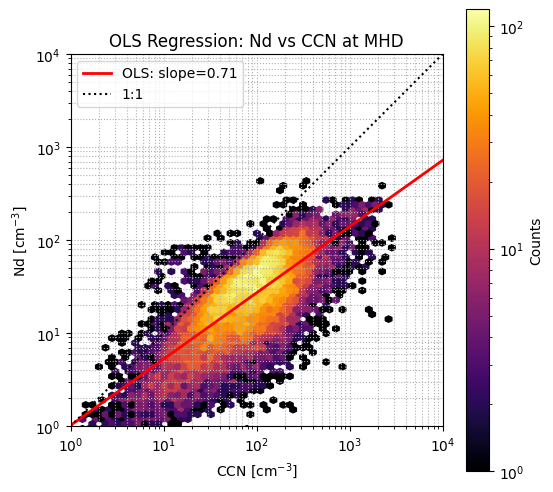

In [9]:
model, AllLevOLSGraph = Function.OLSGraph(CCN_ds.sel(radius= 35), Nor_ds['CDNC'], summary = False, title = f'OLS Regression: Nd vs CCN at {station}')


In [10]:
def compute_allLev(CCN_ds, CDNC_da):
    """
    Compute OLS and TLS slope/intercept per radius,
    flattening across all levels and times.
    Returns a Dataset with variables: slope_OLS, intercept_OLS, slope_TLS, intercept_TLS
    """
    # Align CCN and CDNC over lev and time
    CCN_aligned, CDNC_aligned = xr.align(CCN_ds, CDNC_da)

    # Broadcast CDNC to match CCN dimensions
    CDNC_broadcast = CDNC_aligned.broadcast_like(CCN_aligned)

    # --- OLS ---
    slope_OLS, intercept_OLS = xr.apply_ufunc(
        Function.OLS_fit,
        np.log10(CCN_aligned),
        np.log10(CDNC_broadcast),
        input_core_dims=[['lev', 'time'], ['lev', 'time']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float],
    )

    # --- TLS ---
    slope_TLS, intercept_TLS = xr.apply_ufunc(
        Function.TLS_fit,
        np.log10(CCN_aligned),
        np.log10(CDNC_broadcast),
        input_core_dims=[['lev', 'time'], ['lev', 'time']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float],
    )
    
    # --- Deming ---
    slope_Deming, intercept_Deming = xr.apply_ufunc(
        Function.deming_fit,
        np.log10(CCN_aligned),
        np.log10(CDNC_broadcast),
        input_core_dims=[['lev', 'time'], ['lev', 'time']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float],
    )
    # --- PCA ---
    slope_PCA, intercept_PCA = xr.apply_ufunc(
        Function.PCA_fit,
        np.log10(CCN_aligned),
        np.log10(CDNC_broadcast),
        input_core_dims=[['lev', 'time'], ['lev', 'time']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float],
    )


    # Package into dataset
    ds_out = xr.Dataset(
        data_vars={
            'All_Level_OLS_slope': (('radius',), slope_OLS.data),
            'All_Level_OLS_intercept': (('radius',), intercept_OLS.data),
            'All_Level_TLS_slope': (('radius',), slope_TLS.data),
            'All_Level_TLS_intercept': (('radius',), intercept_TLS.data),
            'All_Level_Deming_slope': (('radius',), slope_Deming.data),
            'All_Level_Deming_intercept': (('radius',), intercept_Deming.data),
            'All_Level_PCA_slope': (('radius',), slope_PCA.data),
            'All_Level_PCA_intercept': (('radius',), intercept_PCA.data),
        },
        coords={'radius': CCN_aligned.radius}
    )

    return ds_out

In [11]:
Susceptibility_AllLevs = compute_allLev(CCN_ds, Nor_ds['CDNC'])
Susceptibility_ds = xr.merge([Level_susc_ds, Susceptibility_AllLevs])

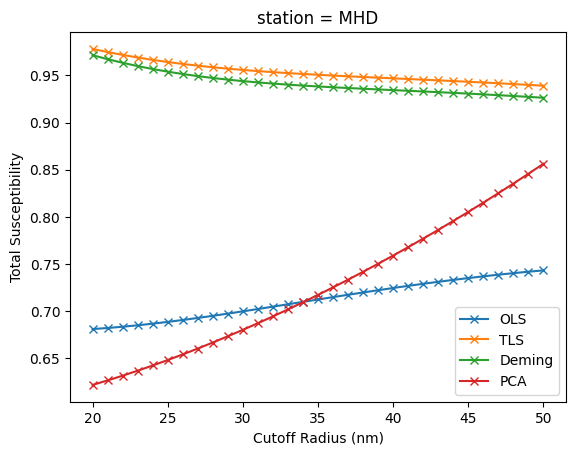

In [12]:
Susceptibility_AllLevs['All_Level_OLS_slope'].plot(marker = 'x', label = 'OLS')
Susceptibility_AllLevs['All_Level_TLS_slope'].plot(marker = 'x', label = 'TLS')
Susceptibility_AllLevs['All_Level_Deming_slope'].plot(marker = 'x', label = 'Deming')
Susceptibility_AllLevs['All_Level_PCA_slope'].plot(marker = 'x', label = 'PCA')
plt.ylabel('Total Susceptibility')
plt.xlabel('Cutoff Radius (nm)')
plt.legend()



In [13]:
def TLSbootstrap(
    x, y, n_bootstrap=1000, random_state=None, plot=True,
    title='TLS Bootstrap Regression: Nd vs CCN'
):
    """
    Perform Total Least Squares regression,
    optional bootstrapped confidence intervals and shared hexbin plotting.
    """

    # --- Clean and log-transform ---
    x = np.asarray(x).ravel()
    y = np.asarray(y).ravel()
    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x, y = x[mask], y[mask]
    X, Y = np.log10(x), np.log10(y)

    n = len(X)
    rng = np.random.default_rng(random_state)

    # --- Main fit ---
    slope, intercept = Function.TLS_fit(X, Y)
    R = np.corrcoef(X, Y)[0, 1]

    # --- Bootstrap resampling ---
    slopes = np.empty(n_bootstrap)
    intercepts = np.empty(n_bootstrap)
    for i in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        slopes[i], intercepts[i] = Function.TLS_fit(X[idx], Y[idx])

    slope_CI = np.percentile(slopes, [2.5, 97.5])
    intercept_CI = np.percentile(intercepts, [2.5, 97.5])

    # --- Print summary ---
    print(f"TLS slope = {slope:.3f} (95% CI {slope_CI[0]:.3f}, {slope_CI[1]:.3f})")
    print(f"Intercept = {intercept:.3f} (95% CI {intercept_CI[0]:.3f}, {intercept_CI[1]:.3f})")
    print(f"Correlation R = {R:.3f}")

    results = {
        "slope": slope,
        "intercept": intercept,
        "R": R,
        "slope_CI": slope_CI,
        "intercept_CI": intercept_CI
    }

    # --- Plot (optional) ---
    fig, ax = None, None
    if plot:
        fits = [{
            'slope': slope,
            'intercept': intercept,
            'label': f"TLS: slope={slope:.2f} [95% CI {slope_CI[0]:.2f}, {slope_CI[1]:.2f}]",
            'style': 'g--'
        }]

        fig, ax = Function.plot_hexbin_regression_multi(
            x, y, fits=fits,
            title=title
        )

    return results, (fig, ax)


TLS slope = 0.951 (95% CI 0.938, 0.964)
Intercept = -0.442 (95% CI -0.467, -0.416)
Correlation R = 0.740


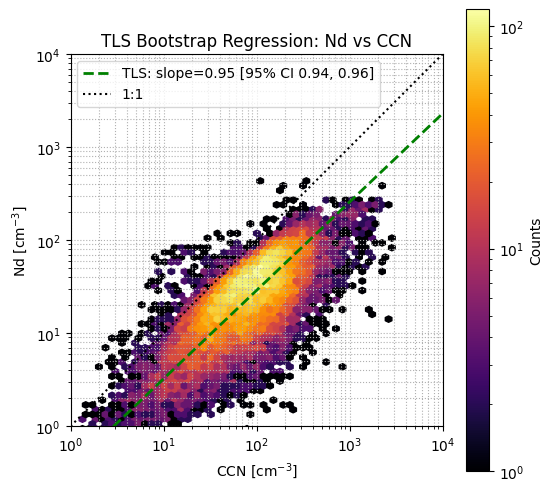

In [14]:

results, (fig, ax) = TLSbootstrap(
    CCN_ds.sel(radius=35),
    Nor_ds['CDNC'],
    n_bootstrap=500,  # faster
    random_state=42,
    plot = True
)
plt.show()

In [15]:
def compare_fits(CCN_ds, Nor_ds, radius=35, plot_tls=True, plot_odr=True, plot_deming=True, plot_ols=True, plot_PCA = True):
    """
    Compare OLS, TLS, and ODR fits for Nd vs CCN (log–log space).
    """

    # --- Prepare data ---
    x = CCN_ds.sel(radius=radius).to_numpy().ravel()
    y = Nor_ds['CDNC'].to_numpy().ravel()

    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x, y = x[mask], y[mask]
    X_log, Y_log = np.log10(x), np.log10(y)

    fits = []  # store all regression results

    # --- OLS ---
    if plot_ols:
        X_design = sm.add_constant(X_log)
        ols_model = sm.OLS(Y_log, X_design).fit()
        ols_slope, ols_intercept = ols_model.params[1], ols_model.params[0]
        fits.append({
            'slope': ols_slope,
            'intercept': ols_intercept,
            'label': f'OLS: slope={ols_slope:.2f}',
            'style': 'r-'
        })
        print("\n--- OLS Fit ---")
        print(ols_model.summary())

    # --- TLS (SVD-based) Same result as ODR when strech = False---
    if plot_tls:
        tls_slope, tls_intercept = Function.TLS_SVD_fit(X_log, Y_log)

        fits.append({
            'slope': tls_slope,
            'intercept': tls_intercept,
            'label': f'TLS: slope={tls_slope:.2f}',
            'style': 'g-.'
        })

        print("\n--- TLS Fit ---")
        print(f"Slope: {tls_slope:.4f}")
        print(f"Intercept: {tls_intercept:.4f}")

    # --- ODR ---
    if plot_odr:
        odr_slope, odr_intercept, out = Function.ODR_fit(X_log, Y_log, stretch = False)
        fits.append({Function
            'slope': odr_slope,
            'intercept': odr_intercept,
            'label': f'ODR: slope={odr_slope:.2f}',
            'style': 'b--'
        })
        print("\n--- ODR Fit ---")
        out.pprint()

    # --- Deming ---
    if plot_deming:
        deming_slope, deming_intercept = Function.deming_fit(X_log, Y_log)
        fits.append({
            'slope': deming_slope,
            'intercept': deming_intercept,
            'label': f'Deming: slope={deming_slope:.2f}',
            'style': 'p--'
        })
        print("\n--- Deming Fit ---")
        print(f"Slope: {deming_slope:.4f}")
        print(f"Intercept: {deming_intercept:.4f}")

    # --- PCA ---
    if plot_PCA:
        PCA_slope, PCA_intercept = Function.PCA_fit(X_log, Y_log)
        fits.append({
            'slope': PCA_slope,
            'intercept': PCA_intercept,
            'label': f'PCA: slope={PCA_slope:.2f}',
            'style': 'o--'
        })
        print("\n--- PCA Fit ---")
        print(f"Slope: {PCA_slope:.4f}")
        print(f"Intercept: {PCA_intercept:.4f}")
        
    # --- Plot all fits together ---
    fig, ax = Function.plot_hexbin_regression_multi(
        x, y,
        fits=fits,
        lims=(1, 1e4),
        title=f"Comparison of Fits (radius={radius} nm)"
    )

    return fig, ax



--- OLS Fit ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.547
Model:                            OLS   Adj. R-squared:                  0.547
Method:                 Least Squares   F-statistic:                 2.152e+04
Date:                Fri, 24 Oct 2025   Prob (F-statistic):               0.00
Time:                        14:45:01   Log-Likelihood:                -3299.9
No. Observations:               17837   AIC:                             6604.
Df Residuals:                   17835   BIC:                             6619.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0087      0.009   

(<Figure size 600x600 with 2 Axes>,
 <Axes: title={'center': 'Comparison of Fits (radius=35 nm)'}, xlabel='CCN [cm$^{-3}$]', ylabel='Nd [cm$^{-3}$]'>)

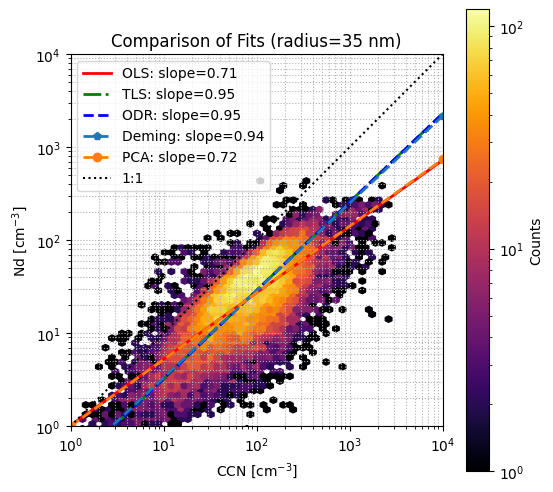

In [16]:
compare_fits(CCN_ds, Nor_ds)

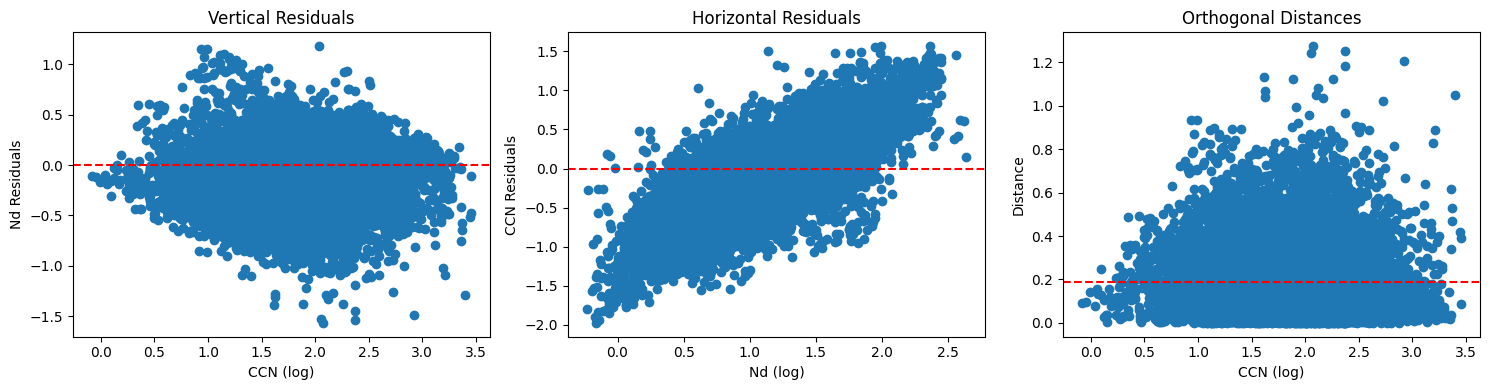


--- TLS Assumption Test ---
OLS slope: 0.7124, intercept: 0.0087
Var(x residuals): 0.2016, Var(y residuals): 0.0848
Variance ratio: 2.3784
Orthogonal residuals mean ± std: 0.1886 ± 0.1438
TLS recommendation: Use ODR with explicit errors


In [18]:
def test_tls_assumptions(X_log, Y_log, plot=True, var_ratio_threshold=2, ortho_std_threshold=0.2):
    """
    Test assumptions for TLS and give a practical recommendation.

    Parameters
    ----------
    X_log : array-like
        log-transformed x values
    Y_log : array-like
        log-transformed y values
    plot : bool
        If True, generates diagnostic plots
    var_ratio_threshold : float
        Maximum allowed variance ratio for TLS to be considered reasonable
    ortho_std_threshold : float
        Maximum allowed orthogonal residual standard deviation (relative scale)

    Returns
    -------
    summary : dict
        Summary including TLS recommendation
    """

    # --- Fit initial OLS in log–log space ---
    X_design = sm.add_constant(X_log)
    ols_model = sm.OLS(Y_log, X_design).fit()
    slope, intercept = ols_model.params[1], ols_model.params[0]

    # --- Residuals ---
    y_pred = intercept + slope * X_log
    res_y = Y_log - y_pred
    res_x = X_log - X_log.mean()

    # --- Orthogonal distances ---
    orthogonal_dist = np.abs(slope*(X_log - X_log.mean()) - (Y_log - Y_log.mean())) / np.sqrt(1 + slope**2)

    # --- Variances ---
    var_x = np.var(res_x, ddof=1)
    var_y = np.var(res_y, ddof=1)
    var_ratio = var_x / var_y if var_x > var_y else var_y / var_x

    # --- TLS recommendation ---
    if var_ratio <= var_ratio_threshold and np.std(orthogonal_dist) <= ortho_std_threshold:
        tls_recommendation = "TLS/SVD reasonable"
    else:
        tls_recommendation = "Use ODR with explicit errors"

    # --- Diagnostic summary ---
    summary = {
        "OLS slope": slope,
        "OLS intercept": intercept,
        "Var(x residuals)": var_x,
        "Var(y residuals)": var_y,
        "Variance ratio": var_ratio,
        "Orthogonal residuals mean": np.mean(orthogonal_dist),
        "Orthogonal residuals std": np.std(orthogonal_dist),
        "TLS recommendation": tls_recommendation
    }

    # --- Plots ---
    if plot:
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        axes[0].scatter(X_log, res_y)
        axes[0].axhline(0, color='r', ls='--')
        axes[0].set_title("Vertical Residuals")
        axes[0].set_xlabel("CCN (log)")
        axes[0].set_ylabel("Nd Residuals")

        axes[1].scatter(Y_log, res_x)
        axes[1].axhline(0, color='r', ls='--')
        axes[1].set_title("Horizontal Residuals")
        axes[1].set_xlabel("Nd (log)")
        axes[1].set_ylabel("CCN Residuals")

        axes[2].scatter(X_log, orthogonal_dist)
        axes[2].axhline(np.mean(orthogonal_dist), color='r', ls='--')
        axes[2].set_title("Orthogonal Distances")
        axes[2].set_xlabel("CCN (log)")
        axes[2].set_ylabel("Distance")

        plt.tight_layout()
        plt.show()

    # --- Print summary ---
    print("\n--- TLS Assumption Test ---")
    print(f"OLS slope: {slope:.4f}, intercept: {intercept:.4f}")
    print(f"Var(x residuals): {var_x:.4f}, Var(y residuals): {var_y:.4f}")
    print(f"Variance ratio: {var_ratio:.4f}")
    print(f"Orthogonal residuals mean ± std: {np.mean(orthogonal_dist):.4f} ± {np.std(orthogonal_dist):.4f}")
    print(f"TLS recommendation: {tls_recommendation}")

    return summary, res_x ,res_y
x = CCN_ds.sel(radius=35).to_numpy().ravel()
y = Nor_ds['CDNC'].to_numpy().ravel()

mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
x, y = x[mask], y[mask]
X_log, Y_log = np.log10(x), np.log10(y)
PCA = Function.PCA_fit(X_log, Y_log)
summary, res_x ,res_y = test_tls_assumptions(X_log, Y_log)

(array([  11.,   32.,  222.,  935., 3030., 5684., 6642., 1181.,   68.,
          32.]),
 array([-1.56519713, -1.29086076, -1.0165244 , -0.74218803, -0.46785167,
        -0.19351531,  0.08082106,  0.35515742,  0.62949379,  0.90383015,
         1.17816652]),
 <BarContainer object of 10 artists>)

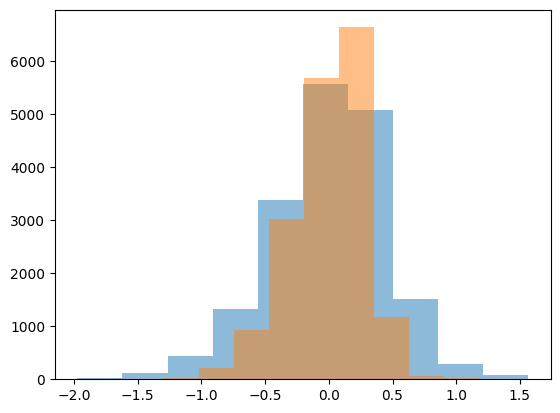

In [19]:
plt.hist(res_x, alpha = .5)
plt.hist(res_y, alpha = 0.5)

In [20]:
Susceptibility_ds

<xarray.Dataset> Size: 66kB
Dimensions:                     (radius: 31, lev: 32)
Coordinates:
    station                     <U8 32B 'MHD'
  * radius                      (radius) int64 248B 20 21 22 23 ... 47 48 49 50
  * lev                         (lev) float64 256B 3.643 7.595 ... 976.3 992.6
Data variables: (12/16)
    OLS slope                   (radius, lev) float64 8kB dask.array<chunksize=(1, 32), meta=np.ndarray>
    OLS intercept               (radius, lev) float64 8kB dask.array<chunksize=(1, 32), meta=np.ndarray>
    ODR slope                   (radius, lev) float64 8kB dask.array<chunksize=(1, 32), meta=np.ndarray>
    ODR intercept               (radius, lev) float64 8kB dask.array<chunksize=(1, 32), meta=np.ndarray>
    Deming slope                (radius, lev) float64 8kB dask.array<chunksize=(1, 32), meta=np.ndarray>
    Deming intercept            (radius, lev) float64 8kB dask.array<chunksize=(1, 32), meta=np.ndarray>
    ...                          ...
    All_Level_TLS_slope         (radius) float64 248B dask.array<chunksize=(1,), meta=np.ndarray>
    All_Level_TLS_intercept     (radius) float64 248B dask.array<chunksize=(1,), meta=np.ndarray>
    All_Level_Deming_slope      (radius) float64 248B dask.array<chunksize=(1,), meta=np.ndarray>
    All_Level_Deming_intercept  (radius) float64 248B dask.array<chunksize=(1,), meta=np.ndarray>
    All_Level_PCA_slope         (radius) float64 248B dask.array<chunksize=(1,), meta=np.ndarray>
    All_Level_PCA_intercept     (radius) float64 248B dask.array<chunksize=(1,), meta=np.ndarray>